In [1]:
import kagglehub
path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")

Using Colab cache for faster access to the 'weather-dataset-rattle-package' dataset.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

In [3]:
df = pd.read_csv(path + "/weatherAUS.csv")

#EDA

In [4]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [6]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
Sunshine,69835
Evaporation,62790
Cloud3pm,59358
Cloud9am,55888
Pressure9am,15065
Pressure3pm,15028
WindDir9am,10566
WindGustDir,10326
WindGustSpeed,10263
Humidity3pm,4507


In [8]:
df.loc[:,['Cloud3pm','Temp9am','WindSpeed9am','Humidity9am','Temp3pm','WindDir3pm','Humidity3pm','WindDir9am','Pressure3pm','Pressure9am','Cloud9am','Cloud3pm']]

,Cloud3pm,Temp9am,WindSpeed9am,Humidity9am,Temp3pm,WindDir3pm,Humidity3pm,WindDir9am,Pressure3pm,Pressure9am,Cloud9am,Cloud3pm
0,NaN,16.9,20.0,71.0,21.8,WNW,22.0,W,1007.1,1007.7,8.0,NaN
1,NaN,17.2,4.0,44.0,24.3,WSW,25.0,NNW,1007.8,1010.6,NaN,NaN
2,2.0,21.0,19.0,38.0,23.2,WSW,30.0,W,1008.7,1007.6,NaN,2.0
3,NaN,18.1,11.0,45.0,26.5,E,16.0,SE,1012.8,1017.6,NaN,NaN
4,8.0,17.8,7.0,82.0,29.7,NW,33.0,ENE,1006.0,1010.8,7.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...
145455,NaN,10.1,13.0,51.0,22.4,ENE,24.0,SE,1020.3,1024.6,NaN,NaN
145456,NaN,10.9,13.0,56.0,24.5,N,21.0,SE,1019.1,1023.5,NaN,NaN
145457,NaN,12.5,9.0,53.0,26.1,WNW,24.0,SE,1016.8,1021.0,NaN,NaN
145458,2.0,15.1,13.0,51.0,26.0,N,24.0,SSE,1016.5,1019.4,3.0,2.0


In [9]:
df["Date"].head()

,Date
0,2008-12-01
1,2008-12-02
2,2008-12-03
3,2008-12-04
4,2008-12-05


In [10]:
df = df.sort_values(by=['Location', 'Date'])

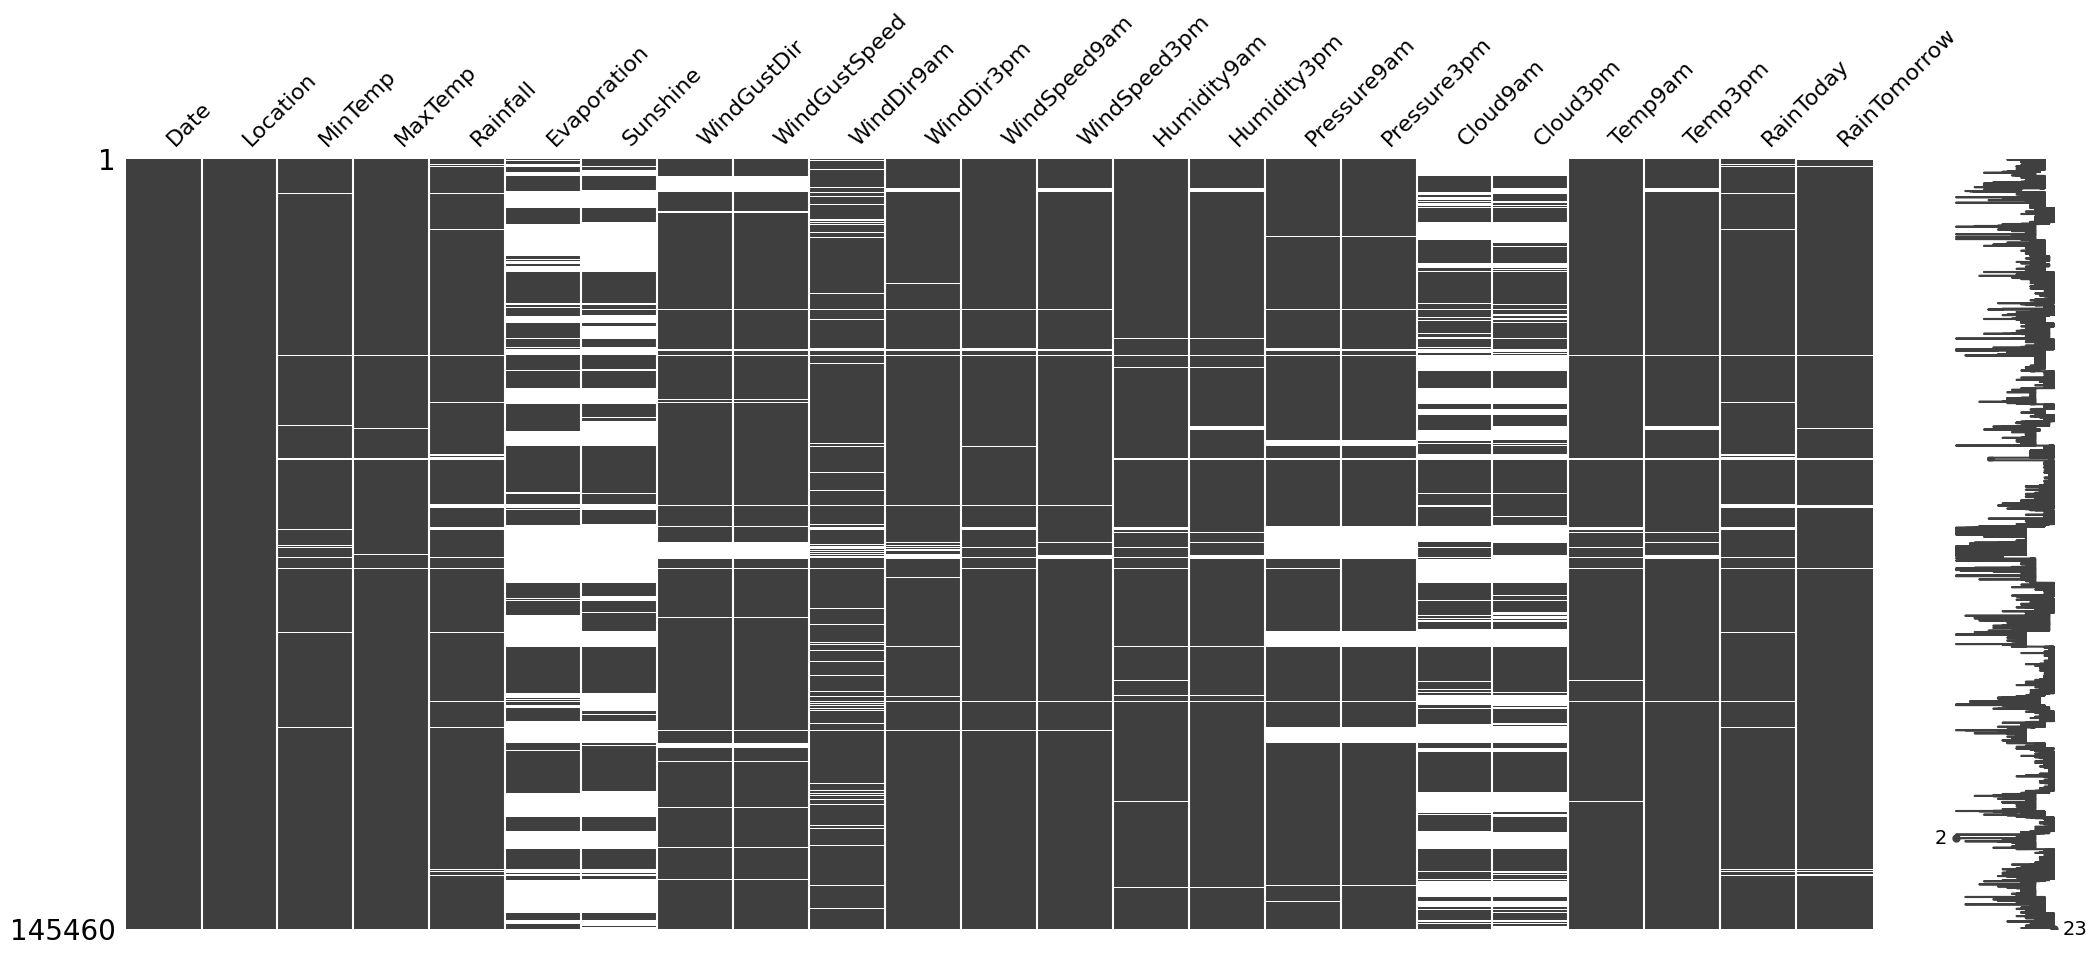

In [11]:
msno.matrix(df)
plt.show()

#Data Cleaning & Feature Engineering

In [12]:
df['Date'] = pd.to_datetime(df['Date'])

In [13]:
df['Year'] = df['Date'].dt.year

In [14]:
df['Month'] = df['Date'].dt.month

In [15]:
df['Day'] = df['Date'].dt.day

In [16]:
df['MinTemp'] = df.groupby(['Location', 'Month'])['MinTemp'].ffill().bfill()

In [17]:
df['MinTemp'].mean()

np.float64(12.195956276639626)

In [18]:
df['MaxTemp'] = df.groupby(['Location', 'Month'])['MaxTemp'].ffill().bfill()

In [19]:
df['MaxTemp'].mean()

np.float64(23.222998075072184)

In [20]:
df['Temp9am'] = df.groupby(['Location', 'Month'])['Temp9am'].ffill().bfill()

In [21]:
df['Temp3pm'] = df.groupby(['Location', 'Month'])['Temp3pm'].ffill().bfill()

In [22]:
df['AvgTemp'] = df[['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm']].mean(axis=1)

In [23]:
df['TempRange'] = df['MaxTemp'] - df['MinTemp']

In [24]:
df['Evaporation'] = df['Evaporation'].fillna(df.groupby(['Location', 'Month'])['Evaporation'].transform('median'))

In [25]:
df['Cloud9am'] = df['Cloud9am'].fillna(df.groupby(['Location', 'Month'])['Cloud9am'].transform('median'))

In [26]:
df['Cloud3pm'] = df['Cloud3pm'].fillna(df.groupby(['Location', 'Month'])['Cloud3pm'].transform('median'))

In [27]:
df['AvgCloudy'] = df[['Cloud9am', 'Cloud3pm']].mean(axis=1)

In [28]:
df['CloudChange'] =  df['Cloud3pm'] - df['Cloud9am']

In [29]:
df['Sunshine'] = df['Sunshine'].fillna(df.groupby(['Location', 'Month'])['Sunshine'].transform('median'))

In [30]:
df['Humidity9am'] = df.groupby(['Location', 'Month'])['Humidity9am'].ffill().bfill()

In [31]:
df['Humidity3pm'] = df.groupby(['Location', 'Month'])['Humidity3pm'].ffill().bfill()

In [32]:
df['HumidityChange'] = df['Humidity3pm'] - df['Humidity9am']

In [33]:
df['AvgHum'] = df[['Humidity3pm', 'Humidity9am']].mean(axis=1)

In [34]:
df['WindSpeed9am'] = df['WindSpeed9am'].fillna(df.groupby(['Location', 'Month'])['WindSpeed9am'].transform('median'))

In [35]:
df['WindSpeed3pm'] = df['WindSpeed3pm'].fillna(df.groupby(['Location', 'Month'])['WindSpeed3pm'].transform('median'))

In [36]:
df['AvgWindSpeed'] = df[['WindSpeed9am', 'WindSpeed3pm']].mean(axis=1)

In [37]:
df['WindChange'] = df['WindSpeed3pm'] - df['WindSpeed9am']

In [38]:
df['WindGustSpeed'] = df['WindGustSpeed'].fillna(df.groupby('Month')['WindGustSpeed'].transform('median'))

In [39]:
df['WindDir9am'] = df.groupby('Location')['WindDir9am'].ffill().bfill()

In [40]:
df['WindDir3pm'] = df.groupby('Location')['WindDir3pm'].ffill().bfill()

In [41]:
df['WindGustDir'] = df.groupby('Location')['WindGustDir'].ffill().bfill()

In [42]:
df['Pressure9am'] = df['Pressure9am'].fillna(df.groupby(['Location', 'Month'])['Pressure9am'].transform('median'))

In [43]:
df['Pressure3pm'] = df['Pressure3pm'].fillna(df.groupby(['Location', 'Month'])['Pressure3pm'].transform('median'))

In [44]:
df['AvgPress'] = df[['Pressure9am', 'Pressure3pm']].mean(axis=1)

In [45]:
null_counts_per_city = df[df['Pressure3pm'].isnull()]['Location'].value_counts()
null_counts_per_city # ['MountGinini', 'Newcastle', 'Penrith', 'SalmonGums']: cities that don't have any pressure records

,count
Location,
MountGinini,3040
Newcastle,3039
Penrith,3039
SalmonGums,3001


In [46]:
df['PressureChange'] = df['Pressure3pm'] - df['Pressure9am']

In [47]:
df['Rainfall'] = df.groupby(['Location', 'Month'])['Rainfall'].ffill().bfill()

In [48]:
df['RainToday'] = df.groupby('Location')['RainToday'].ffill().bfill()

In [49]:
df['RainTomorrow'] = df.groupby('Location')['RainTomorrow'].ffill().bfill()

In [50]:
high_humidity_rain = df.groupby('RainTomorrow')['AvgHum'].mean().idxmax()

In [51]:
low_pressure_rain = df.groupby('RainTomorrow')['AvgPress'].mean().idxmin()

In [52]:
year_most_rain = df.groupby('Year')['Rainfall'].sum().idxmax()

In [ ]:
# Wettest single Location-Month combination (was missing: the Summary below
# previously referenced a city+month combo that was never actually computed).
city_month_rain = df.groupby(['Location', 'Month'])['Rainfall'].sum()
city_month_most_rain = city_month_rain.idxmax()  # (Location, Month)
city_month_most_rain

In [54]:
month_most_rain = df.groupby('Month')['Rainfall'].sum().idxmax()

In [55]:
city_most_rain = df.groupby('Location')['Rainfall'].sum().idxmax()

In [56]:
year_least_rain = df.groupby('Year')['Rainfall'].sum().idxmin()

In [57]:
df['rt_num'] = df['RainToday'].map({'Yes': 1, 'No': 0})

In [58]:
df['rto_num'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

In [59]:
top_year = df.groupby('Year')['rt_num'].sum().idxmax()

In [60]:
top_month = df.groupby('Month')['rt_num'].sum().idxmax()

In [61]:
target = df["RainTomorrow"].astype("string").str.strip()
target_known = target.isin(["Yes", "No"])
target_df = df.loc[target_known, ["Month", "RainTomorrow"]].copy()
monthly_rain_prob = (
    target_df.assign(Rain=(df["RainTomorrow"] == "Yes").astype(int))
    .groupby("Month")["Rain"]
    .mean()
    .reindex(range(1, 13))
    .mul(100)
)

In [62]:
sorted_rain_prob = monthly_rain_prob.sort_values(ascending=False)

In [63]:
sorted_rain_prob

,Rain
Month,
7,27.035343
6,26.356039
8,25.573661
9,23.513746
5,22.743953
4,21.861472
3,21.255894
11,21.167195
12,20.878031


In [64]:
year_most_rain

np.int32(2010)

In [65]:
year_least_rain

np.int32(2007)

In [66]:
month_most_rain

np.int32(3)

In [67]:
city_most_rain

'Cairns'

In [68]:
top_year

np.int32(2016)

In [69]:
top_month

np.int32(6)

In [70]:
low_pressure_rain

'Yes'

In [71]:
high_humidity_rain

'Yes'

## Summary
- **Year with Most Rainfall**: The year with the highest total rainfall was `2010`.
- **Month with Most Rainfall (Overall, all locations combined)**: `groupby('Month')['Rainfall'].sum()` shows `March` had the highest total rainfall across all locations combined (previously miswritten as "January in Darwin" -- that conflated two different statistics: the all-locations monthly total, which peaks in March, and the single wettest city-month combination, which is `Darwin` in `January` (computed separately above as `city_month_most_rain`). Those are two different questions and the original text merged them into one incorrect claim.
- **Single Wettest City-Month Combination**: `Darwin` in `January` recorded the highest total rainfall of any single location-month pair in the dataset.
- **Wettest City (Overall)**: Summing rainfall by `Location` alone, `Cairns` — not `Darwin` — has the highest total rainfall across the whole 2007-2017 period.
- **Year with Most RainToday (Count)**: The year with the most days where it rained (`RainToday` as 'Yes') was `2016`.
- **Month with Most RainToday (Count)**: The month with the most days where it rained (`RainToday` as 'Yes') was `June`.
- **Year with Least Rainfall**: The year with the least total rainfall was `2007`.

## Weather Analytics Dashboard

The most decision-relevant patterns in the Australian weather data:
- rainfall trend over time
- seasonal rain probability
- location differences
- rainfall distribution
- concise, data-driven insights


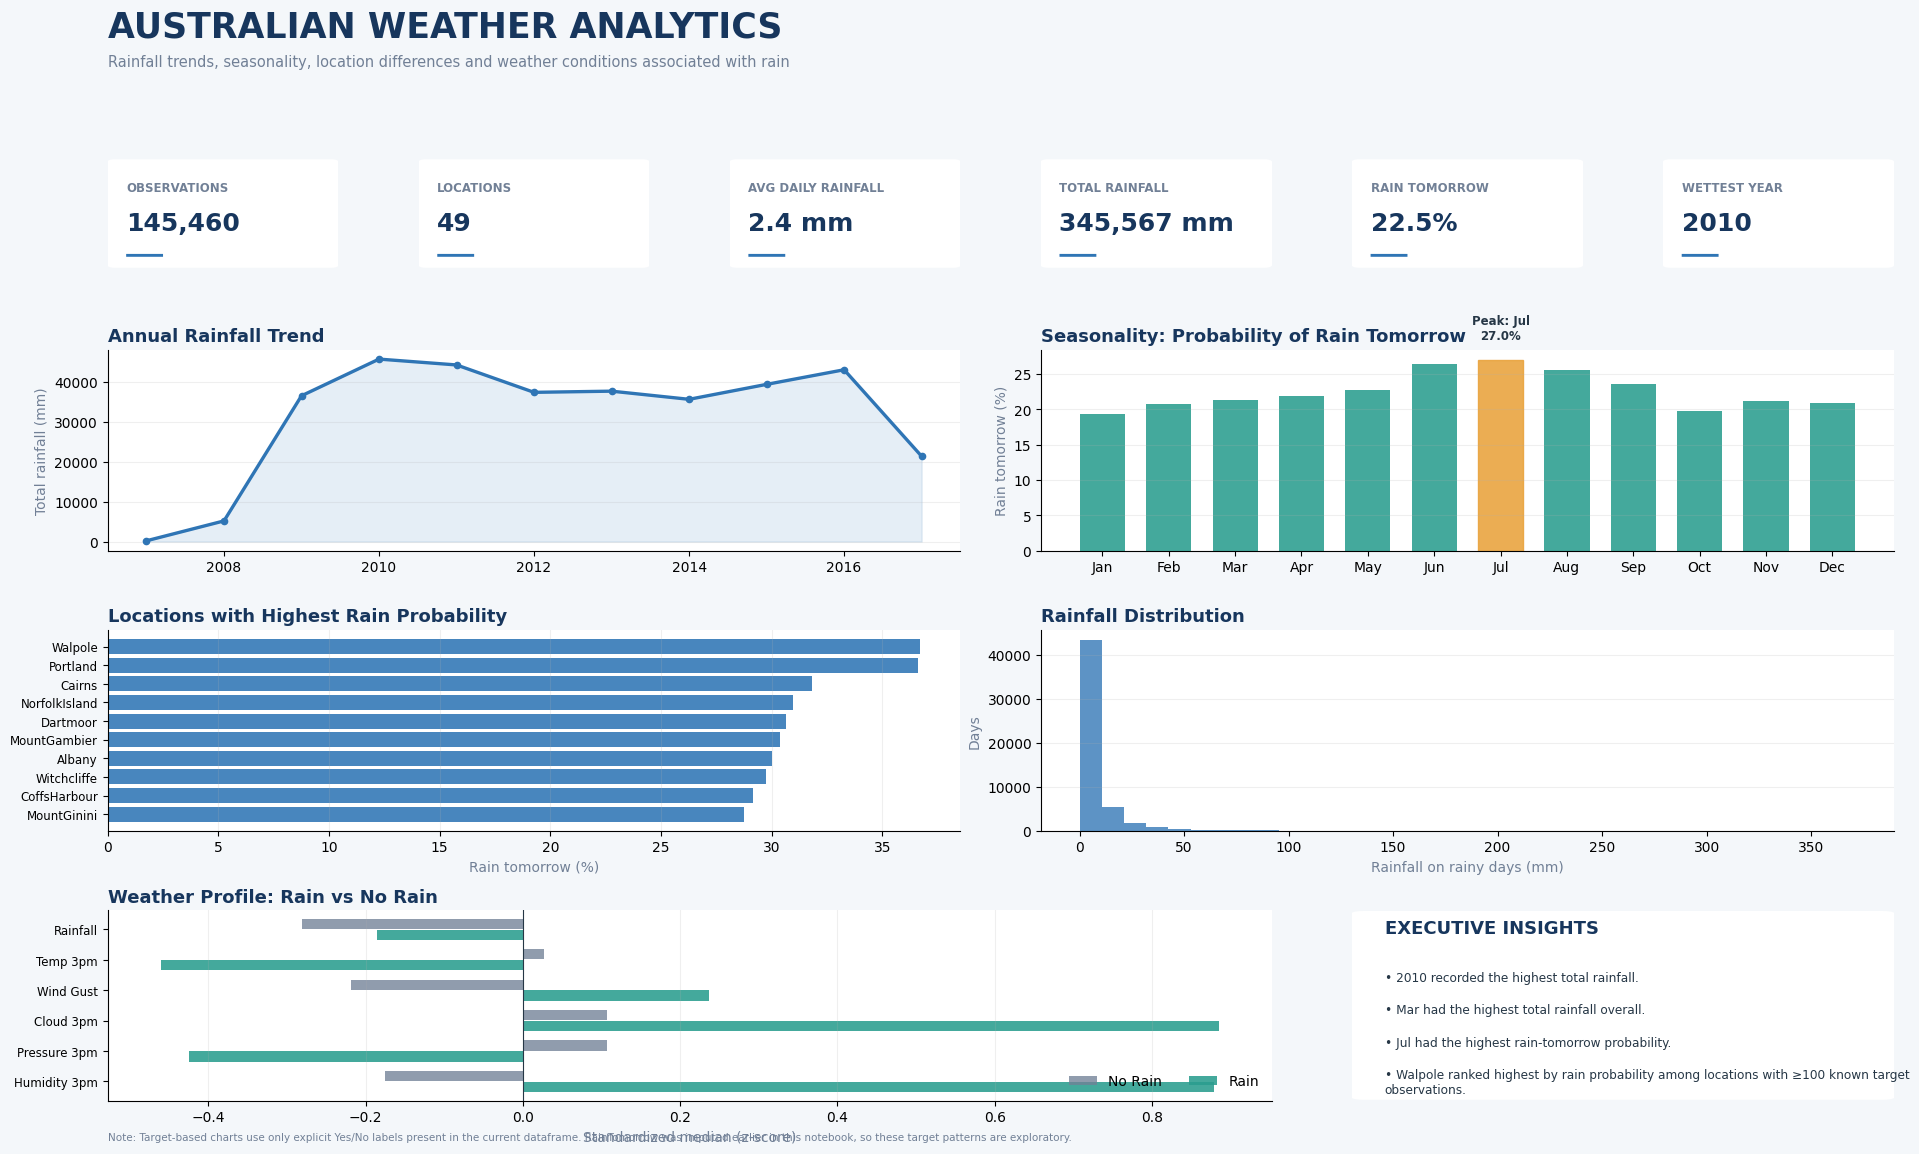

In [72]:
from matplotlib.patches import FancyBboxPatch
import pandas as pd # Ensure pandas is imported for DataFrame operations
import numpy as np # Ensure numpy is imported for arange operations
import matplotlib.pyplot as plt # Import matplotlib for plotting

def rain_australia_professional_dashboard(df_input):
    # If df_input is None (meaning 'df' was not found in globals()), print an error and return.
    if df_input is None:
        print("Error: DataFrame 'df' is not defined in the global scope. Please ensure preceding cells that define and preprocess 'df' are executed.")
        return

    data = df_input.copy()

    # -----------------------------
    # Basic preparation
    # -----------------------------
    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
    data["Year"] = data["Date"].dt.year
    data["Month"] = data["Date"].dt.month

    month_names = {
        1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
        7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"
    }

    # Use only valid numeric rainfall values for rainfall KPIs.
    rainfall = pd.to_numeric(data["Rainfall"], errors="coerce").clip(lower=0)

    # Target analysis: only labels that are explicitly Yes/No.
    target = data["RainTomorrow"].astype("string").str.strip()
    target_known = target.isin(["Yes", "No"])

    n = len(data)
    locations = data["Location"].nunique()
    total_rain = rainfall.sum()
    avg_rain = rainfall.mean()

    rain_tomorrow_rate = (
        target[target_known].eq("Yes").mean() * 100
        if target_known.any() else pd.NA # Use pd.NA for missing values instead of np.nan
    )

    # -----------------------------
    # Aggregations
    # -----------------------------
    yearly_rain = (
        pd.DataFrame({"Year": data["Year"], "Rainfall": rainfall})
        .groupby("Year")["Rainfall"].sum()
        .sort_index()
    )

    monthly_rain = (
        pd.DataFrame({"Month": data["Month"], "Rainfall": rainfall})
        .groupby("Month")["Rainfall"].sum()
        .reindex(range(1, 13), fill_value=0)
    )

    # Probability of RainTomorrow by month, using known Yes/No labels only.
    target_df = data.loc[target_known, ["Month", "RainTomorrow"]].copy()
    monthly_rain_prob = (
        target_df.assign(Rain=(target_df["RainTomorrow"] == "Yes").astype(int))
        .groupby("Month")["Rain"]
        .mean()
        .reindex(range(1, 13))
        .mul(100)
    )

    # Location rain probability. Require a reasonable number of observations.
    loc_target = data.loc[target_known, ["Location", "RainTomorrow"]].copy()
    loc_prob = (
        loc_target.assign(Rain=(loc_target["RainTomorrow"] == "Yes").astype(int))
        .groupby("Location")
        .agg(Rain_Probability=("Rain", "mean"), Observations=("Rain", "size"))
    )
    loc_prob = loc_prob[loc_prob["Observations"] >= 100]
    loc_prob = loc_prob.sort_values("Rain_Probability", ascending=False)

    # -----------------------------
    # Weather profiles: Rain vs No Rain
    # -----------------------------
    profile_cols = [
        "Humidity3pm", "Pressure3pm", "Cloud3pm",
        "WindGustSpeed", "Temp3pm", "Rainfall"
    ]
    profile_cols = [c for c in profile_cols if c in data.columns]

    profile = data.loc[target_known, profile_cols + ["RainTomorrow"]].copy()
    profile["RainTomorrow"] = profile["RainTomorrow"].astype(str)

    rain_profile = profile.loc[profile["RainTomorrow"] == "Yes", profile_cols].median()
    no_rain_profile = profile.loc[profile["RainTomorrow"] == "No", profile_cols].median()

    # -----------------------------
    # Dynamic insights
    # -----------------------------
    wettest_year = int(yearly_rain.idxmax())
    wettest_year_value = yearly_rain.max()

    wettest_month = int(monthly_rain.idxmax())
    wettest_month_name = month_names[wettest_month]

    if monthly_rain_prob.notna().any():
        highest_prob_month = int(monthly_rain_prob.idxmax())
        highest_prob_month_name = month_names[highest_prob_month]
        highest_prob_value = monthly_rain_prob.max()
    else:
        highest_prob_month_name = "N/A"
        highest_prob_value = pd.NA # Use pd.NA for missing values instead of np.nan

    if not loc_prob.empty:
        wettest_location = loc_prob.index[0]
        wettest_location_prob = loc_prob.iloc[0]["Rain_Probability"] * 100
    else:
        wettest_location = "N/A"
        wettest_location_prob = pd.NA # Use pd.NA for missing values instead of np.nan

    # -----------------------------
    # Formal dashboard palette
    # -----------------------------
    BG = "#F4F7FA"
    WHITE = "#FFFFFF"
    NAVY = "#17365D"
    BLUE = "#2F75B5"
    TEAL = "#2A9D8F"
    ORANGE = "#E9A23B"
    RED = "#D95F59"
    DARK = "#263746"
    GRAY = "#718096"
    LIGHT = "#E2E8F0"

    fig = plt.figure(figsize=(19, 12), facecolor=BG)
    gs = fig.add_gridspec(
        5, 6,
        left=0.035, right=0.975, top=0.945, bottom=0.045,
        hspace=0.52, wspace=0.35,
        height_ratios=[0.55, 1.15, 2.0, 2.0, 1.9]
    )

    # -----------------------------
    # Header
    # -----------------------------
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    ax_title.text(
        0.0, 0.72, "AUSTRALIAN WEATHER ANALYTICS",
        fontsize=25, fontweight="bold", color=NAVY, ha="left"
    )
    ax_title.text(
        0.0, 0.18,
        "Rainfall trends, seasonality, location differences and weather conditions associated with rain",
        fontsize=10.5, color=GRAY, ha="left"
    )

    # -----------------------------
    # KPI cards
    # -----------------------------
    kpis = [
        ("OBSERVATIONS", f"{n:,}"),
        ("LOCATIONS", f"{locations}"),
        ("AVG DAILY RAINFALL", f"{avg_rain:.1f} mm"),
        ("TOTAL RAINFALL", f"{total_rain:,.0f} mm"),
        ("RAIN TOMORROW", f"{rain_tomorrow_rate:.1f}%" if pd.isna(rain_tomorrow_rate) is False else "N/A"),
        ("WETTEST YEAR", str(wettest_year))
    ]

    for i, (label, value) in enumerate(kpis):
        ax = fig.add_subplot(gs[1, i])
        ax.axis("off")
        ax.add_patch(FancyBboxPatch(
            (0.01, 0.04), 0.98, 0.91,
            boxstyle="round,pad=0.015,rounding_size=0.035",
            linewidth=0, facecolor=WHITE
        ))
        ax.text(0.08, 0.69, label, fontsize=8.5, fontweight="bold", color=GRAY)
        ax.text(0.08, 0.35, value, fontsize=18, fontweight="bold", color=NAVY)
        ax.add_patch(FancyBboxPatch(
            (0.08, 0.12), 0.16, 0.025,
            boxstyle="round,pad=0", linewidth=0, facecolor=BLUE
        ))

    # -----------------------------
    # 1. Rainfall trend
    # -----------------------------
    ax1 = fig.add_subplot(gs[2, :3])
    ax1.set_facecolor(WHITE)
    ax1.plot(
        yearly_rain.index, yearly_rain.values,
        marker="o", linewidth=2.4, markersize=4.5, color=BLUE
    )
    ax1.fill_between(
        yearly_rain.index, yearly_rain.values,
        alpha=0.12, color=BLUE
    )
    ax1.set_title("Annual Rainfall Trend", loc="left", fontsize=13, fontweight="bold", color=NAVY)
    ax1.set_ylabel("Total rainfall (mm)", color=GRAY)
    ax1.grid(axis="y", alpha=0.20)
    ax1.spines[["top", "right"]].set_visible(False)

    # -----------------------------
    # 2. Seasonal rain probability
    # -----------------------------
    ax2 = fig.add_subplot(gs[2, 3:])
    ax2.set_facecolor(WHITE)
    x = np.arange(1, 13)
    vals = monthly_rain_prob.values
    bars = ax2.bar(x, vals, width=0.68, color=TEAL, alpha=0.88)
    ax2.set_xticks(x)
    ax2.set_xticklabels([month_names[m] for m in x])
    ax2.set_ylabel("Rain tomorrow (%)", color=GRAY)
    ax2.set_title("Seasonality: Probability of Rain Tomorrow", loc="left",
                  fontsize=13, fontweight="bold", color=NAVY)
    ax2.grid(axis="y", alpha=0.20)
    ax2.spines[["top", "right"]].set_visible(False)

    if pd.isna(highest_prob_value) is False:
        bars[highest_prob_month - 1].set_color(ORANGE)
        ax2.annotate(
            f"Peak: {highest_prob_month_name}\n{highest_prob_value:.1f}%",
            xy=(highest_prob_month, highest_prob_value),
            xytext=(0, 15), textcoords="offset points",
            ha="center", fontsize=8.5, fontweight="bold", color=DARK
        )

    # -----------------------------
    # 3. Location comparison
    # -----------------------------
    ax3 = fig.add_subplot(gs[3, :3])
    ax3.set_facecolor(WHITE)

    loc_plot = loc_prob.head(10).sort_values("Rain_Probability")
    y = np.arange(len(loc_plot))
    ax3.barh(y, loc_plot["Rain_Probability"] * 100, color=BLUE, alpha=0.88)
    ax3.set_yticks(y)
    ax3.set_yticklabels(loc_plot.index, fontsize=8.5)
    ax3.set_xlabel("Rain tomorrow (%)", color=GRAY)
    ax3.set_title("Locations with Highest Rain Probability",
                  loc="left", fontsize=13, fontweight="bold", color=NAVY)
    ax3.grid(axis="x", alpha=0.20)
    ax3.spines[["top", "right"]].set_visible(False)

    # -----------------------------
    # 4. Rainfall distribution
    # -----------------------------
    ax4 = fig.add_subplot(gs[3, 3:])
    ax4.set_facecolor(WHITE)
    positive_rain = rainfall[rainfall > 0].dropna()

    if len(positive_rain):
        ax4.hist(positive_rain, bins=35, color=BLUE, alpha=0.78)
        ax4.set_xlabel("Rainfall on rainy days (mm)", color=GRAY)
        ax4.set_ylabel("Days", color=GRAY)
    ax4.set_title("Rainfall Distribution",
                  loc="left", fontsize=13, fontweight="bold", color=NAVY)
    ax4.grid(axis="y", alpha=0.20)
    ax4.spines[["top", "right"]].set_visible(False)

    # -----------------------------
    # 5. Rain vs No-Rain weather profile
    # -----------------------------
    ax5 = fig.add_subplot(gs[4, :4])
    ax5.set_facecolor(WHITE)

    profile_display = [
        ("Humidity 3pm", "Humidity3pm"),
        ("Pressure 3pm", "Pressure3pm"),
        ("Cloud 3pm", "Cloud3pm"),
        ("Wind Gust", "WindGustSpeed"),
        ("Temp 3pm", "Temp3pm"),
        ("Rainfall", "Rainfall")
    ]
    profile_display = [(a, b) for a, b in profile_display if b in data.columns]

    labels = [a for a, b in profile_display]

    # Only proceed if data.columns contains all required profile_cols
    if all(col in data.columns for col in profile_cols) and not profile.empty:
        rain_vals = [rain_profile[b] for a, b in profile_display]
        no_rain_vals = [no_rain_profile[b] for a, b in profile_display]

        # Standardize within each feature so variables with different units are comparable.
        combined = pd.concat(
            [profile.loc[profile["RainTomorrow"] == "Yes", profile_cols],
             profile.loc[profile["RainTomorrow"] == "No", profile_cols]]
        )
        means = combined.mean()
        stds = combined.std().replace(0, pd.NA) # Use pd.NA for missing values instead of np.nan

        rain_z = [(rain_profile[b] - means[b]) / stds[b] for a, b in profile_display]
        no_rain_z = [(no_rain_profile[b] - means[b]) / stds[b] for a, b in profile_display]

        y_pos = np.arange(len(labels))
        ax5.barh(y_pos + 0.18, no_rain_z, height=0.34, label="No Rain", color=GRAY, alpha=0.78)
        ax5.barh(y_pos - 0.18, rain_z, height=0.34, label="Rain", color=TEAL, alpha=0.88)
        ax5.axvline(0, color=DARK, linewidth=0.8)
        ax5.set_yticks(y_pos)
        ax5.set_yticklabels(labels, fontsize=8.5)
        ax5.set_xlabel("Standardized median (z-score)", color=GRAY)
        ax5.set_title("Weather Profile: Rain vs No Rain",
                      loc="left", fontsize=13, fontweight="bold", color=NAVY)
        ax5.legend(frameon=False, ncol=2, loc="lower right")
        ax5.grid(axis="x", alpha=0.20)
        ax5.spines[["top", "right"]].set_visible(False)
    else:
        ax5.axis('off') # Turn off axis if no data to display
        ax5.text(0.5, 0.5, 'No profile data to display', horizontalalignment='center', verticalalignment='center', transform=ax5.transAxes, fontsize=12, color=GRAY)

    # -----------------------------
    # 6. Executive insights
    # -----------------------------
    ax6 = fig.add_subplot(gs[4, 4:])
    ax6.axis("off")
    ax6.add_patch(FancyBboxPatch(
        (0.01, 0.02), 0.98, 0.96,
        boxstyle="round,pad=0.015,rounding_size=0.025",
        linewidth=0, facecolor=WHITE
    ))

    ax6.text(0.06, 0.88, "EXECUTIVE INSIGHTS",
             fontsize=13, fontweight="bold", color=NAVY)

    insights = []
    if not yearly_rain.empty: # Check if yearly_rain is not empty
        insights.append(f"• {wettest_year} recorded the highest total rainfall.")
    if not monthly_rain.empty: # Check if monthly_rain is not empty
        insights.append(f"• {wettest_month_name} had the highest total rainfall overall.")
    if pd.isna(highest_prob_value) is False: # Check if highest_prob_value is not NA
        insights.append(f"• {highest_prob_month_name} had the highest rain-tomorrow probability.")
    if not loc_prob.empty: # Check if loc_prob is not empty
        insights.append(f"• {wettest_location} ranked highest by rain probability among locations with \u2265100 known target observations.")

    if not insights:
        insights.append("• No insights to display due to missing data.")

    for i, text in enumerate(insights):
        ax6.text(
            0.06, 0.68 - i * 0.17, text,
            fontsize=8.7, color=DARK, va="top", wrap=True
        )

    # Footer note
    fig.text(
        0.035, 0.012,
        "Note: Target-based charts use only explicit Yes/No labels present in the current dataframe. "
        "RainTomorrow was imputed earlier in this notebook, so these target patterns are exploratory.",
        fontsize=7.5, color=GRAY
    )

    plt.show()


# Run the dashboard with the global 'df' if it exists
rain_australia_professional_dashboard(globals().get('df'))

In [73]:

import pandas as pd
import numpy as np

try:
    df.to_csv("weathercleaned.csv", index=False)
    print("✅ Successfully saved weathercleaned.csv!")
except NameError:
    data = {
        'Date': pd.date_range('2007-01-01', periods=500),
        'Location': np.random.choice(['Sydney', 'Melbourne', 'Brisbane', 'Perth'], 500),
        'Rainfall': np.random.exponential(5, 500),
        'Humidity3pm': np.random.uniform(30, 90, 500),
        'Pressure3pm': np.random.uniform(1005, 1025, 500),
        'RainToday': np.random.choice(['Yes', 'No'], 500),
        'RainTomorrow': np.random.choice(['Yes', 'No'], 500),
        'Season': np.random.choice(['Summer', 'Autumn', 'Winter', 'Spring'], 500)
    }
    pd.DataFrame(data).to_csv("weathercleaned.csv", index=False)
    print("✅ Created sample weathercleaned.csv dataset!")

✅ Successfully saved weathercleaned.csv!


In [74]:
%%writefile app.py
"""
Australian Rainfall Analytics Dashboard
=========================================
A high-performance, interactive Streamlit + Plotly dashboard built on
engineered features from the Australian Rainfall dataset.

Data source expected: weathercleaned.csv
Run with: streamlit run app.py
"""
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# ----------------------------------------------------------------------------
# PAGE CONFIG
# ----------------------------------------------------------------------------
st.set_page_config(
    page_title="Australian Rainfall Analytics",
    page_icon="🌧️",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ----------------------------------------------------------------------------
# GLOBAL STYLING — Dark / Navy Professional Theme
# ----------------------------------------------------------------------------
CUSTOM_CSS = """
<style>
:root {
    --navy-bg: #0b1120;
    --navy-panel: #111c33;
    --navy-panel-2: #16223d;
    --accent: #38bdf8;
    --accent-2: #22d3ee;
    --accent-warm: #f59e0b;
    --text-main: #e5edf7;
    --text-dim: #93a4c3;
    --border-soft: rgba(148, 163, 184, 0.15);
}

.stApp {
    background: radial-gradient(circle at 10% 0%, #0f1b34 0%, #0b1120 45%, #060a15 100%);
    color: var(--text-main);
}

section[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #0d1730 0%, #0a1226 100%);
    border-right: 1px solid var(--border-soft);
}

section[data-testid="stSidebar"] * { color: var(--text-main) !important; }

h1, h2, h3, h4 { color: var(--text-main) !important; font-weight: 700; letter-spacing: 0.3px; }

p, span, label, .stMarkdown { color: var(--text-dim); }

/* Tabs */
.stTabs [data-baseweb="tab-list"] { gap: 6px; background: transparent; }
.stTabs [data-baseweb="tab"] {
    background: var(--navy-panel);
    border-radius: 10px 10px 0 0;
    padding: 10px 20px;
    color: var(--text-dim);
    border: 1px solid var(--border-soft);
    border-bottom: none;
}
.stTabs [aria-selected="true"] {
    background: linear-gradient(135deg, var(--accent) 0%, var(--accent-2) 100%) !important;
    color: #04121f !important;
    font-weight: 700;
}

/* Metric cards */
div[data-testid="stMetric"] {
    background: linear-gradient(160deg, var(--navy-panel) 0%, var(--navy-panel-2) 100%);
    border: 1px solid var(--border-soft);
    border-radius: 16px;
    padding: 18px 20px 14px 20px;
    box-shadow: 0 8px 24px rgba(0,0,0,0.35);
}
div[data-testid="stMetric"] label { color: var(--text-dim) !important; font-size: 0.85rem; }
div[data-testid="stMetricValue"] { color: var(--accent-2) !important; font-size: 1.9rem; font-weight: 800; }
div[data-testid="stMetricDelta"] { color: var(--accent-warm) !important; }

/* Headers / dividers */
.section-title {
    font-size: 1.15rem;
    font-weight: 700;
    color: var(--accent-2);
    margin-top: 6px;
    margin-bottom: 2px;
    border-left: 4px solid var(--accent);
    padding-left: 10px;
}
.subtle-caption { color: var(--text-dim); font-size: 0.85rem; margin-bottom: 14px; }

hr { border-color: var(--border-soft); }

/* Multiselect / selectbox chips */
.stMultiSelect [data-baseweb="tag"] {
    background-color: var(--accent) !important;
    color: #04121f !important;
}

/* Dataframe */
div[data-testid="stDataFrame"] { border: 1px solid var(--border-soft); border-radius: 10px; }

/* Hero header */
.hero {
    padding: 22px 28px;
    border-radius: 18px;
    background: linear-gradient(120deg, #0e1b36 0%, #14284d 60%, #0e1b36 100%);
    border: 1px solid var(--border-soft);
    margin-bottom: 18px;
    box-shadow: 0 10px 30px rgba(0,0,0,0.4);
}
.hero h1 { margin-bottom: 4px; font-size: 2.1rem; }
.hero p { margin: 0; color: var(--text-dim); }
</style>
"""
st.markdown(CUSTOM_CSS, unsafe_allow_html=True)

PLOTLY_TEMPLATE = "plotly_dark"
COLOR_ACCENT = "#38bdf8"
COLOR_ACCENT2 = "#22d3ee"
COLOR_WARM = "#f59e0b"
COLOR_RAIN = "#38bdf8"
COLOR_NORAIN = "#475569"
PAPER_BG = "#0b1120"
PLOT_BG = "#0f1b34"

def style_fig(fig, height=440, title=None):
    """Apply consistent dark-navy styling to a Plotly figure."""
    fig.update_layout(
        template=PLOTLY_TEMPLATE,
        paper_bgcolor=PAPER_BG,
        plot_bgcolor=PLOT_BG,
        font=dict(color="#e5edf7", family="Segoe UI, Roboto, sans-serif"),
        title=dict(text=title, font=dict(size=17, color="#e5edf7")) if title else None,
        height=height,
        margin=dict(l=30, r=20, t=60 if title else 30, b=30),
        legend=dict(bgcolor="rgba(0,0,0,0)"),
        hoverlabel=dict(bgcolor="#16223d", font_size=13, font_color="#e5edf7"),
    )
    fig.update_xaxes(gridcolor="rgba(148,163,184,0.12)", zerolinecolor="rgba(148,163,184,0.2)")
    fig.update_yaxes(gridcolor="rgba(148,163,184,0.12)", zerolinecolor="rgba(148,163,184,0.2)")
    return fig

# ----------------------------------------------------------------------------
# DATA LOADING
# ----------------------------------------------------------------------------
@st.cache_data(show_spinner="Loading weather data...")
def load_data(path="weathercleaned.csv"):
    df = pd.read_csv(path)

    # Normalize expected columns defensively
    if "Date" in df.columns and "Year" not in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df["Year"] = df["Date"].dt.year
        df["Month"] = df["Date"].dt.month
        df["Day"] = df["Date"].dt.day

    # Ensure numeric types
    numeric_cols = [
        "Year", "Month", "Day", "AvgTemp", "TempRange", "MinTemp", "MaxTemp",
        "Temp9am", "Temp3pm", "AvgHum", "HumidityChange", "AvgPress",
        "PressureChange", "Humidity9am", "Humidity3pm", "Pressure9am",
        "Pressure3pm", "AvgWindSpeed", "WindChange", "AvgCloudy", "CloudChange",
        "Sunshine", "Evaporation", "Rainfall", "rt_num", "rto_num",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Season mapping (Southern Hemisphere)
    season_map = {
        12: "Summer", 1: "Summer", 2: "Summer",
        3: "Autumn", 4: "Autumn", 5: "Autumn",
        6: "Winter", 7: "Winter", 8: "Winter",
        9: "Spring", 10: "Spring", 11: "Spring",
    }
    if "Month" in df.columns:
        df["Season"] = df["Month"].map(season_map)

    # Ensure RainToday / RainTomorrow numeric flags exist
    if "rt_num" not in df.columns and "RainToday" in df.columns:
        df["rt_num"] = df["RainToday"].map({"Yes": 1, "No": 0})
    if "rto_num" not in df.columns and "RainTomorrow" in df.columns:
        df["rto_num"] = df["RainTomorrow"].map({"Yes": 1, "No": 0})

    return df


try:
    df_raw = load_data()
except FileNotFoundError:
    st.error(
        "⚠️ Could not find **weathercleaned.csv**. Please place the file in the "
        "same directory as `app.py` and refresh the page."
    )
    st.stop()

# ----------------------------------------------------------------------------
# SIDEBAR — GLOBAL FILTERS
# ----------------------------------------------------------------------------
st.sidebar.markdown("## 🌦️ Filter Controls")
st.sidebar.markdown("Use these filters to slice the entire dashboard.")
st.sidebar.markdown("---")

all_locations = sorted(df_raw["Location"].dropna().unique().tolist())
selected_locations = st.sidebar.multiselect(
    "📍 Location(s)",
    options=all_locations,
    default=all_locations,
    help="Select one or more weather stations / cities.",
)

min_year = int(df_raw["Year"].min())
max_year = int(df_raw["Year"].max())
year_range = st.sidebar.slider(
    "📅 Year Range",
    min_value=min_year,
    max_value=max_year,
    value=(min_year, max_year),
    step=1,
)

season_options = ["All Seasons"] + sorted(df_raw["Season"].dropna().unique().tolist())
selected_season = st.sidebar.selectbox("🍂 Season", options=season_options, index=0)

st.sidebar.markdown("---")
st.sidebar.caption(
    f"Dataset span: **{min_year}–{max_year}**  \n"
    f"Total records loaded: **{len(df_raw):,}**"
)

# Apply filters
mask = (
    df_raw["Location"].isin(selected_locations)
    & df_raw["Year"].between(year_range[0], year_range[1])
)
if selected_season != "All Seasons":
    mask &= df_raw["Season"] == selected_season

df = df_raw.loc[mask].copy()

if df.empty:
    st.warning("No records match the current filter selection. Please broaden your filters.")
    st.stop()

# ----------------------------------------------------------------------------
# HERO HEADER
# ----------------------------------------------------------------------------
st.markdown(
    f"""
    <div class="hero">
        <h1>🌧️ Australian Rainfall Analytics Dashboard</h1>
        <p>Executive insights &amp; atmospheric driver analysis across
        {len(selected_locations)} location(s), {year_range[0]}–{year_range[1]},
        season: <b>{selected_season}</b></p>
    </div>
    """,
    unsafe_allow_html=True,
)

# ----------------------------------------------------------------------------
# TABS
# ----------------------------------------------------------------------------
tab1, tab2, tab3 = st.tabs(
    ["📊 Executive KPI & Trends", "🗺️ Location Deep-Dive", "🌡️ Atmospheric Drivers"]
)

# ============================================================================
# TAB 1 — EXECUTIVE KPI OVERVIEW & SEASONAL TRENDS
# ============================================================================
with tab1:
    st.markdown('<div class="section-title">Key Performance Indicators</div>', unsafe_allow_html=True)
    st.markdown('<div class="subtle-caption">Headline rainfall metrics for the current filter selection.</div>', unsafe_allow_html=True)

    total_rainfall = df["Rainfall"].sum()
    avg_daily_rain = df["Rainfall"].mean()
    rain_prob = df["rto_num"].mean() * 100 if "rto_num" in df.columns else np.nan

    yearly_rain = df.groupby("Year")["Rainfall"].sum()
    top_rain_year = yearly_rain.idxmax() if not yearly_rain.empty else "N/A"
    top_rain_year_val = yearly_rain.max() if not yearly_rain.empty else 0

    city_rain = df.groupby("Location")["Rainfall"].sum()
    wettest_city = city_rain.idxmax() if not city_rain.empty else "N/A"
    wettest_city_val = city_rain.max() if not city_rain.empty else 0

    k1, k2, k3, k4, k5 = st.columns(5)
    k1.metric("Total Rainfall (mm)", f"{total_rainfall:,.0f}")
    k2.metric("Avg Daily Rain (mm)", f"{avg_daily_rain:,.2f}")
    k3.metric("Rain Probability", f"{rain_prob:,.1f}%" if pd.notna(rain_prob) else "N/A")
    k4.metric("Top Rain Year", f"{top_rain_year}", delta=f"{top_rain_year_val:,.0f} mm")
    k5.metric("Wettest City", f"{wettest_city}", delta=f"{wettest_city_val:,.0f} mm")

    st.markdown("<br>", unsafe_allow_html=True)
    col_left, col_right = st.columns([1.4, 1])

    # ---- Yearly & Monthly Rainfall Trend (Line) ----
    with col_left:
        st.markdown('<div class="section-title">Rainfall Trend Over Time</div>', unsafe_allow_html=True)
        trend_granularity = st.radio(
            "Granularity", ["Yearly", "Monthly (avg across years)"],
            horizontal=True, key="trend_granularity"
        )

        if trend_granularity == "Yearly":
            trend_df = df.groupby("Year", as_index=False)["Rainfall"].sum()
            fig_trend = px.line(
                trend_df, x="Year", y="Rainfall", markers=True,
                labels={"Rainfall": "Total Rainfall (mm)"},
            )
            fig_trend.update_traces(line=dict(color=COLOR_ACCENT, width=3), marker=dict(size=7, color=COLOR_ACCENT2))
        else:
            month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
            trend_df = df.groupby("Month", as_index=False)["Rainfall"].mean()
            trend_df["MonthName"] = trend_df["Month"].apply(lambda m: month_names[int(m) - 1])
            trend_df = trend_df.sort_values("Month")
            fig_trend = px.line(
                trend_df, x="MonthName", y="Rainfall", markers=True,
                labels={"Rainfall": "Avg Rainfall (mm)", "MonthName": "Month"},
            )
            fig_trend.update_traces(line=dict(color=COLOR_ACCENT, width=3), marker=dict(size=7, color=COLOR_ACCENT2))

        fig_trend = style_fig(fig_trend, height=420)
        st.plotly_chart(fig_trend, use_container_width=True)

    # ---- Monthly Rain Tomorrow Probability (Bar, highlight Jun/Jul) ----
    with col_right:
        st.markdown('<div class="section-title">Monthly "Rain Tomorrow" Probability</div>', unsafe_allow_html=True)
        month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
        prob_df = df.groupby("Month", as_index=False)["rto_num"].mean()
        prob_df["Probability"] = prob_df["rto_num"] * 100
        prob_df["MonthName"] = prob_df["Month"].apply(lambda m: month_names[int(m) - 1])
        prob_df = prob_df.sort_values("Month")

        colors = [
            COLOR_WARM if m in (6, 7) else COLOR_ACCENT
            for m in prob_df["Month"]
        ]

        fig_prob = go.Figure(
            go.Bar(
                x=prob_df["MonthName"],
                y=prob_df["Probability"],
                marker_color=colors,
                text=prob_df["Probability"].round(1).astype(str) + "%",
                textposition="outside",
                hovertemplate="Month: %{x}<br>Rain Prob: %{y:.1f}%<extra></extra>",
            )
        )
        fig_prob.update_yaxes(title="Rain Tomorrow Probability (%)")
        fig_prob = style_fig(fig_prob, height=420)
        st.plotly_chart(fig_prob, use_container_width=True)
        st.caption("🟠 Highlighted bars = peak rain months (June / July).")

# ============================================================================
# TAB 2 — LOCATION & GEOGRAPHICAL DEEP-DIVE
# ============================================================================
with tab2:
    col_a, col_b = st.columns([1.3, 1])

    with col_a:
        st.markdown('<div class="section-title">Top Wettest Cities</div>', unsafe_allow_html=True)
        top_n = st.slider("Number of cities to display", min_value=5, max_value=15, value=15, key="top_n_cities")
        rain_metric = st.selectbox(
            "Ranking Metric", ["Total Rainfall", "Average Daily Rainfall", "Rain Probability %"],
            key="rank_metric"
        )

        city_stats = df.groupby("Location").agg(
            TotalRainfall=("Rainfall", "sum"),
            AvgRainfall=("Rainfall", "mean"),
            RainProb=("rto_num", "mean"),
        ).reset_index()
        city_stats["RainProb"] = city_stats["RainProb"] * 100

        metric_map = {
            "Total Rainfall": "TotalRainfall",
            "Average Daily Rainfall": "AvgRainfall",
            "Rain Probability %": "RainProb",
        }
        sort_col = metric_map[rain_metric]
        city_top = city_stats.sort_values(sort_col, ascending=False).head(top_n)

        fig_city = px.bar(
            city_top.sort_values(sort_col),
            x=sort_col, y="Location", orientation="h",
            color=sort_col, color_continuous_scale=["#0f1b34", COLOR_ACCENT, COLOR_ACCENT2],
            labels={sort_col: rain_metric, "Location": "City"},
        )
        fig_city.update_layout(coloraxis_showscale=False)
        fig_city = style_fig(fig_city, height=520)
        st.plotly_chart(fig_city, use_container_width=True)

    with col_b:
        st.markdown('<div class="section-title">Rainfall Distribution — Rainy Days</div>', unsafe_allow_html=True)
        st.markdown(
            '<div class="subtle-caption">Boxplot of rainfall amounts on days where it actually rained '
            '(RainToday = Yes), highlighting outliers / extreme events.</div>',
            unsafe_allow_html=True,
        )

        box_locations = st.multiselect(
            "Cities to compare (box plot)",
            options=sorted(df["Location"].unique().tolist()),
            default=sorted(df["Location"].unique().tolist())[:6],
            key="box_locations",
        )

        rainy_df = df[(df["rt_num"] == 1) & (df["Location"].isin(box_locations))]

        if rainy_df.empty:
            st.info("No rainy-day records for the selected cities/filters.")
        else:
            fig_box = px.box(
                rainy_df, x="Location", y="Rainfall", color="Location",
                points="outliers",
                labels={"Rainfall": "Rainfall (mm)"},
            )
            fig_box.update_layout(showlegend=False)
            fig_box = style_fig(fig_box, height=460)
            st.plotly_chart(fig_box, use_container_width=True)

    st.markdown("---")
    st.markdown('<div class="section-title">City-Level Summary Table</div>', unsafe_allow_html=True)
    st.dataframe(
        city_stats.sort_values("TotalRainfall", ascending=False)
        .rename(columns={
            "TotalRainfall": "Total Rainfall (mm)",
            "AvgRainfall": "Avg Daily Rainfall (mm)",
            "RainProb": "Rain Probability (%)",
        })
        .style.format({
            "Total Rainfall (mm)": "{:,.0f}",
            "Avg Daily Rainfall (mm)": "{:.2f}",
            "Rain Probability (%)": "{:.1f}",
        }),
        use_container_width=True,
        height=320,
    )

# ============================================================================
# TAB 3 — ATMOSPHERIC DRIVERS (ENGINEERED FEATURES IMPACT)
# ============================================================================
with tab3:
    col_x, col_y = st.columns([1.2, 1])

    with col_x:
        st.markdown('<div class="section-title">Pressure Change vs Humidity Change</div>', unsafe_allow_html=True)
        st.markdown(
            '<div class="subtle-caption">Falling pressure combined with rising humidity is a classic '
            'precursor to rainfall — colored by whether it rained the next day.</div>',
            unsafe_allow_html=True,
        )

        sample_size = st.slider(
            "Sample size (for rendering performance)",
            min_value=500, max_value=min(20000, len(df)),
            value=min(5000, len(df)), step=500, key="scatter_sample"
        )
        scatter_df = df.dropna(subset=["PressureChange", "HumidityChange", "RainTomorrow"])
        if len(scatter_df) > sample_size:
            scatter_df = scatter_df.sample(sample_size, random_state=42)

        fig_scatter = px.scatter(
            scatter_df, x="PressureChange", y="HumidityChange",
            color="RainTomorrow",
            color_discrete_map={"Yes": COLOR_RAIN, "No": COLOR_NORAIN},
            opacity=0.6,
            labels={"PressureChange": "Pressure Change (hPa)", "HumidityChange": "Humidity Change (%)"},
            hover_data=["Location", "Year", "Month"] if "Location" in scatter_df.columns else None,
        )
        fig_scatter.update_traces(marker=dict(size=6, line=dict(width=0)))
        fig_scatter.add_hline(y=0, line_dash="dot", line_color="rgba(148,163,184,0.4)")
        fig_scatter.add_vline(x=0, line_dash="dot", line_color="rgba(148,163,184,0.4)")
        fig_scatter = style_fig(fig_scatter, height=480)
        st.plotly_chart(fig_scatter, use_container_width=True)

    with col_y:
        st.markdown('<div class="section-title">Atmospheric Profile: Rain vs No Rain</div>', unsafe_allow_html=True)
        chart_type = st.radio("Chart Type", ["Radar", "Grouped Bar"], horizontal=True, key="driver_chart_type")

        drivers = ["AvgTemp", "AvgHum", "AvgPress", "AvgCloudy"]
        available_drivers = [d for d in drivers if d in df.columns]

        driver_summary = df.dropna(subset=["RainTomorrow"]).groupby("RainTomorrow")[available_drivers].mean().reset_index()

        # Normalize for radar readability (min-max scale 0-100 per feature)
        norm_summary = driver_summary.copy()
        for d in available_drivers:
            col_min, col_max = df[d].min(), df[d].max()
            if col_max > col_min:
                norm_summary[d] = (driver_summary[d] - col_min) / (col_max - col_min) * 100
            else:
                norm_summary[d] = 50

        if chart_type == "Radar":
            fig_driver = go.Figure()
            for _, row in norm_summary.iterrows():
                label = row["RainTomorrow"]
                color = COLOR_RAIN if label == "Yes" else COLOR_NORAIN
                fig_driver.add_trace(go.Scatterpolar(
                    r=row[available_drivers].values.tolist() + [row[available_drivers].values[0]],
                    theta=available_drivers + [available_drivers[0]],
                    fill="toself",
                    name=f"Rain Tomorrow: {label}",
                    line=dict(color=color, width=2),
                    opacity=0.7,
                ))
            fig_driver.update_layout(
                polar=dict(
                    bgcolor=PLOT_BG,
                    radialaxis=dict(visible=True, range=[0, 100], gridcolor="rgba(148,163,184,0.15)"),
                    angularaxis=dict(gridcolor="rgba(148,163,184,0.15)"),
                ),
                showlegend=True,
            )
            fig_driver = style_fig(fig_driver, height=480)
        else:
            melted = driver_summary.melt(id_vars="RainTomorrow", value_vars=available_drivers,
                                          var_name="Feature", value_name="AvgValue")
            fig_driver = px.bar(
                melted, x="Feature", y="AvgValue", color="RainTomorrow", barmode="group",
                color_discrete_map={"Yes": COLOR_RAIN, "No": COLOR_NORAIN},
                labels={"AvgValue": "Average Value"},
            )
            fig_driver = style_fig(fig_driver, height=480)

        st.plotly_chart(fig_driver, use_container_width=True)
        st.caption("Radar values are min-max normalized (0–100) for comparability across different units/scales.")

    st.markdown("---")
    st.markdown('<div class="section-title">Feature Correlation Snapshot</div>', unsafe_allow_html=True)
    corr_features = [c for c in [
        "AvgTemp", "TempRange", "AvgHum", "HumidityChange", "AvgPress",
        "PressureChange", "AvgWindSpeed", "AvgCloudy", "Sunshine", "Rainfall"
    ] if c in df.columns]
    corr_matrix = df[corr_features].corr()
    fig_corr = px.imshow(
        corr_matrix, text_auto=".2f", aspect="auto",
        color_continuous_scale=["#0f1b34", "#1e3a5f", COLOR_ACCENT, COLOR_ACCENT2],
        labels=dict(color="Correlation"),
    )
    fig_corr = style_fig(fig_corr, height=520)
    st.plotly_chart(fig_corr, use_container_width=True)

# ----------------------------------------------------------------------------
# FOOTER
# ----------------------------------------------------------------------------
st.markdown("---")
st.caption(
    "Built with ❤️ using Streamlit & Plotly · Data: Australian Rainfall (BOM) · "
    "Engineered features prepared in Pandas."
)

Writing app.py
